In [1]:
#Membuat direktori hdfs
!hdfs dfs -mkdir -p /user/celloz/ecommerce/raw
!hdfs dfs -mkdir -p /user/celloz/ecommerce/processed

#verifikasi direktori
!hdfs dfs -ls /user/celloz/ecommerce

Found 2 items
drwxr-xr-x   - celloz supergroup          0 2026-09-07 10:30 /user/celloz/ecommerce/processed
drwxr-xr-x   - celloz supergroup          0 2026-09-07 10:30 /user/celloz/ecommerce/raw


In [7]:
#Mengunggah file csv ke direktori raw
#!hdfs dfs -put transaksi_magelang.csv transaksi_yogyakarta.csv transaksi_semarang.csv /user/celloz/ecommerce/raw
#Verifikasi file apakah sudah terupload
!hdfs dfs -ls /user/celloz/ecommerce/raw 
#ukuran tiap file
!hdfs dfs -du -h /user/celloz/ecommerce/raw


Found 3 items
-rw-r--r--   1 celloz supergroup      12329 2026-09-07 10:34 /user/celloz/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 celloz supergroup      12154 2026-09-07 10:34 /user/celloz/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 celloz supergroup      12684 2026-09-07 10:34 /user/celloz/ecommerce/raw/transaksi_yogyakarta.csv
12.0 K  12.0 K  /user/celloz/ecommerce/raw/transaksi_magelang.csv
11.9 K  11.9 K  /user/celloz/ecommerce/raw/transaksi_semarang.csv
12.4 K  12.4 K  /user/celloz/ecommerce/raw/transaksi_yogyakarta.csv


In [11]:
#membaca kembali file dari hdfs
import subprocess
import pandas as pd
from io import StringIO

def read(nama_file):
    path=f"/user/celloz/ecommerce/raw/{nama_file}"
    data=subprocess.check_output(
        ["hdfs","dfs","-cat",path]
    ).decode("utf-8")
    return pd.read_csv(StringIO(data))

df_magelang = read("transaksi_magelang.csv")
df_yogyakarta = read("transaksi_yogyakarta.csv")
df_semarang = read("transaksi_semarang.csv")


In [15]:
df_magelang.head()

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang


In [16]:
df_yogyakarta.head(10)

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,YOG-2000,2026-08-20,Fashion,5,250000,E-Wallet,Yogyakarta
1,YOG-2001,2026-08-24,Fashion,4,150000,Kartu Kredit,Yogyakarta
2,YOG-2002,2026-08-29,Rumah Tangga,4,100000,E-Wallet,Yogyakarta
3,YOG-2003,2026-08-13,Fashion,7,250000,E-Wallet,Yogyakarta
4,YOG-2004,2026-08-09,Elektronik,7,75000,COD,Yogyakarta
5,YOG-2005,2026-08-10,Fashion,4,250000,COD,Yogyakarta
6,YOG-2006,2026-08-26,Fashion,1,75000,E-Wallet,Yogyakarta
7,YOG-2007,2026-08-08,Elektronik,5,25000,COD,Yogyakarta
8,YOG-2008,2026-08-07,Kesehatan & Kecantikan,7,25000,COD,Yogyakarta
9,YOG-2009,2026-08-23,Fashion,1,25000,E-Wallet,Yogyakarta


In [23]:
df_semarang.head(15)


,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,SEM-2000,2026-08-28,Elektronik,3,100000,E-Wallet,Semarang
1,SEM-2001,2026-08-29,Kesehatan & Kecantikan,4,25000,Transfer Bank,Semarang
2,SEM-2002,2026-08-19,Rumah Tangga,1,25000,COD,Semarang
3,SEM-2003,2026-08-02,Makanan & Minuman,2,75000,E-Wallet,Semarang
4,SEM-2004,2026-08-05,Elektronik,6,25000,Transfer Bank,Semarang
5,SEM-2005,2026-08-22,Fashion,7,75000,E-Wallet,Semarang
6,SEM-2006,2026-08-13,Fashion,1,100000,Kartu Kredit,Semarang
7,SEM-2007,2026-08-06,Makanan & Minuman,1,250000,Transfer Bank,Semarang
8,SEM-2008,2026-08-22,Fashion,4,50000,Kartu Kredit,Semarang
9,SEM-2009,2026-08-07,Makanan & Minuman,1,50000,Transfer Bank,Semarang


In [21]:
#menggabungkan 3 file csv menjadi satu dataframe
df_gabungan = pd.concat(
    [df_magelang,df_yogyakarta,df_semarang],ignore_index=True
)

In [24]:
df_gabungan


,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang
...,...,...,...,...,...,...,...
595,SEM-2195,2026-08-31,Rumah Tangga,6,75000,Transfer Bank,Semarang
596,SEM-2196,2026-08-15,Kesehatan & Kecantikan,5,75000,Transfer Bank,Semarang
597,SEM-2197,2026-08-01,Makanan & Minuman,4,75000,E-Wallet,Semarang
598,SEM-2198,2026-08-05,Fashion,7,25000,Transfer Bank,Semarang


In [31]:
df_gabungan["kota"].value_counts()

kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64

In [34]:
#menambahkan kolom total pendapatan pada dataframe gabungan
df_gabungan["total_pendapatan"] = (df_gabungan["unit_terjual"]*
                                   df_gabungan["harga_satuan"])
df_gabungan.head(10)

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota,total_pendapatan
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang,50000
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang,175000
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang,175000
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang,150000
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang,700000
5,MAG-2005,2026-08-12,Kesehatan & Kecantikan,7,250000,Kartu Kredit,Magelang,1750000
6,MAG-2006,2026-08-16,Rumah Tangga,4,75000,Kartu Kredit,Magelang,300000
7,MAG-2007,2026-08-10,Kesehatan & Kecantikan,5,250000,Kartu Kredit,Magelang,1250000
8,MAG-2008,2026-08-14,Fashion,6,25000,Kartu Kredit,Magelang,150000
9,MAG-2009,2026-08-09,Rumah Tangga,7,150000,E-Wallet,Magelang,1050000


In [49]:
#meringkas total pendapatan per kota dan per kategori sekaligus
ringkasan_kota_kategori = df_gabungan.groupby(
    ["kota","kategori"]
)["total_pendapatan"].sum().reset_index()
ringkasan_kota_kategori

,kota,kategori,total_pendapatan
0,Magelang,Elektronik,18775000
1,Magelang,Fashion,27750000
2,Magelang,Kesehatan & Kecantikan,17375000
3,Magelang,Makanan & Minuman,17525000
4,Magelang,Rumah Tangga,12200000
5,Semarang,Elektronik,21425000
6,Semarang,Fashion,26425000
7,Semarang,Kesehatan & Kecantikan,13525000
8,Semarang,Makanan & Minuman,19750000
9,Semarang,Rumah Tangga,10975000


In [41]:
#Menyimpan dataframe gabungan dan juga ringkasan
df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
ringkasan_kota_kategori.to_csv("ringkasan_kota_kategori.csv", index=False)

In [52]:
#verifikasi data apakah sudah tersimpan di lokal
!ls -la  data_gabungan_bersih.csv
!ls -la ringkasan_kota_kategori.csv


-rw-rw-r-- 1 celloz celloz 41257 Sep  7 19:16 data_gabungan_bersih.csv
-rw-rw-r-- 1 celloz celloz 530 Sep  7 19:16 ringkasan_kota_kategori.csv


In [53]:
#mengupload file csv diatas ke HDFS
!hdfs dfs -put data_gabungan_bersih.csv /user/celloz/ecommerce/processed/
!hdfs dfs -put ringkasan_kota_kategori.csv /user/celloz/ecommerce/processed/


In [56]:
#verifikasi apakah file sudah ada di sistem HDFS
!hdfs dfs -ls  /user/celloz/ecommerce/processed/

Found 2 items
-rw-r--r--   1 celloz supergroup      41257 2026-09-07 19:24 /user/celloz/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 celloz supergroup        530 2026-09-07 19:24 /user/celloz/ecommerce/processed/ringkasan_kota_kategori.csv


In [ ]:
#Keuntungan menyimpan data raw dan processed secara terpisah di HDFS daripada dicampur jadi satu

#dokumentasi dalam GUI Hadoop

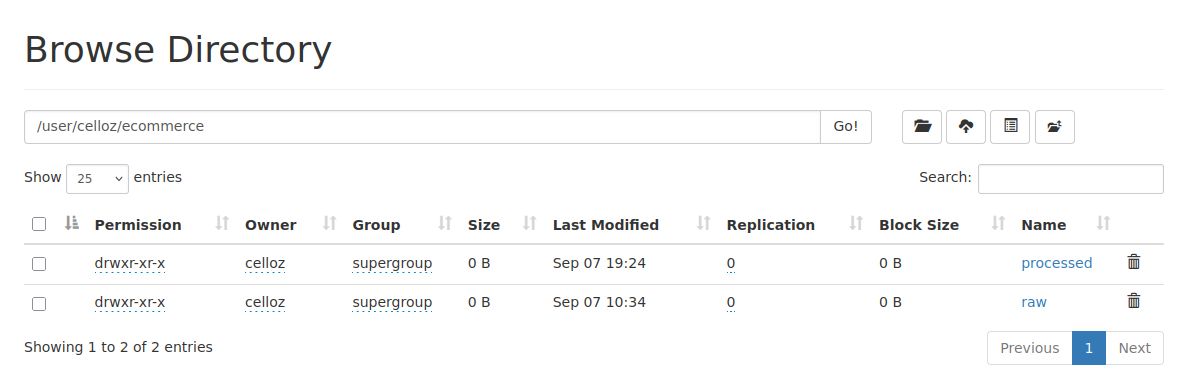
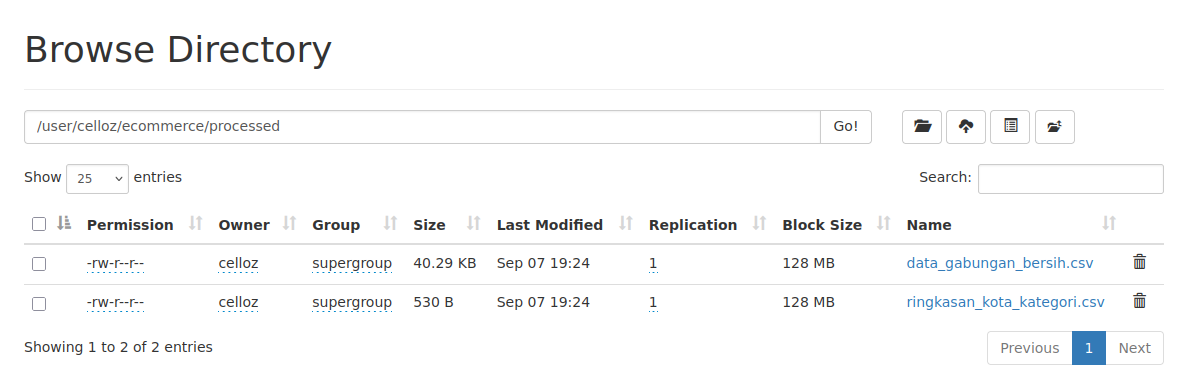
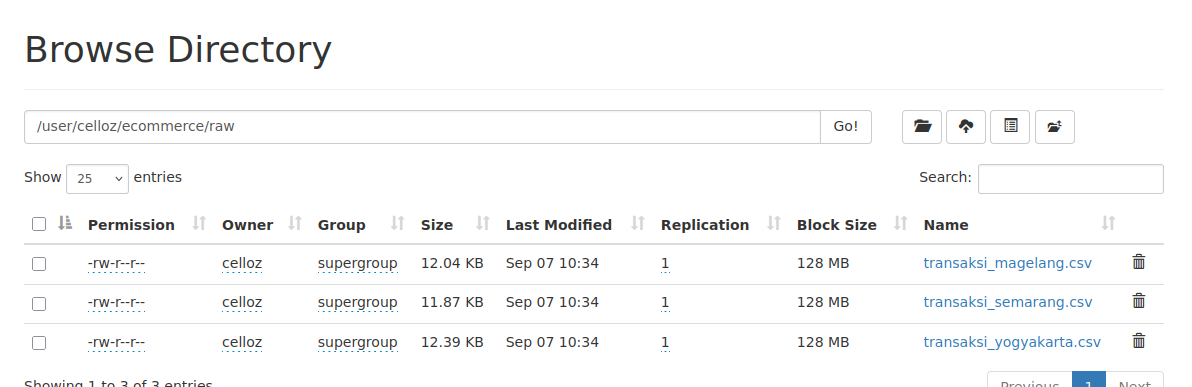